In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

DATA_DIR = os.path.join("Data", "ml-100k")

In [ ]:
# Load the Ratings Data (u.data)
r_cols = ['user_id', 'movie_id', 'rating', 'unix_timestamp']
ratings = pd.read_csv(os.path.join(DATA_DIR, 'u.data'), sep='\t', names=r_cols, encoding='latin-1')
ratings.head()

,user_id,movie_id,rating,unix_timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [ ]:
# Load the User Data (u.user)
u_cols = ['user_id', 'age', 'gender', 'occupation', 'zip_code']
users = pd.read_csv(os.path.join(DATA_DIR, 'u.user'), sep='|', names=u_cols, encoding='latin-1')
users.head()

,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


In [ ]:
# Load the Movie Data (u.item)
i_cols = ['movie_id', 'movie_title', 'release_date', 'video_release_date', 'IMDb_URL']
items = pd.read_csv(os.path.join(DATA_DIR, 'u.item'), sep='|', names=i_cols, 
                    usecols=range(5), encoding='latin-1')

items.head()



,movie_id,movie_title,release_date,video_release_date,IMDb_URL
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995)


In [6]:
print(f"Loaded {len(ratings)} ratings, {len(users)} users, and {len(items)} movies.")

Loaded 100000 ratings, 943 users, and 1682 movies.


# Visualizations

C:\Users\arash\AppData\Local\Temp\ipykernel_37732\1960537303.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=ratings, palette='viridis')


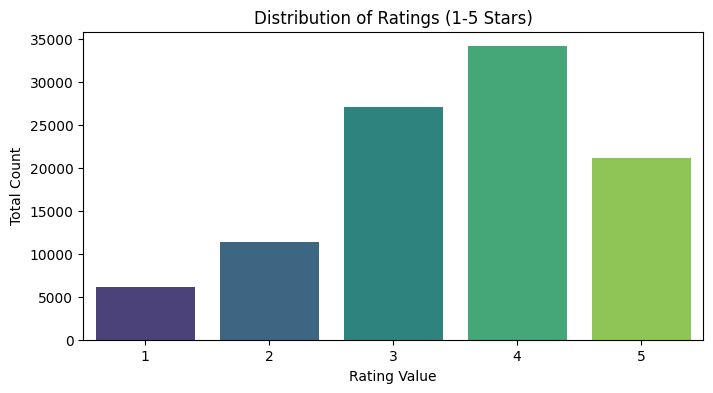

In [ ]:
# Distribution of Ratings 
plt.figure(figsize=(8, 4))
sns.countplot(x='rating', data=ratings, palette='viridis')
plt.title('Distribution of Ratings (1-5 Stars)')
plt.xlabel('Rating Value')
plt.ylabel('Total Count')
plt.show()


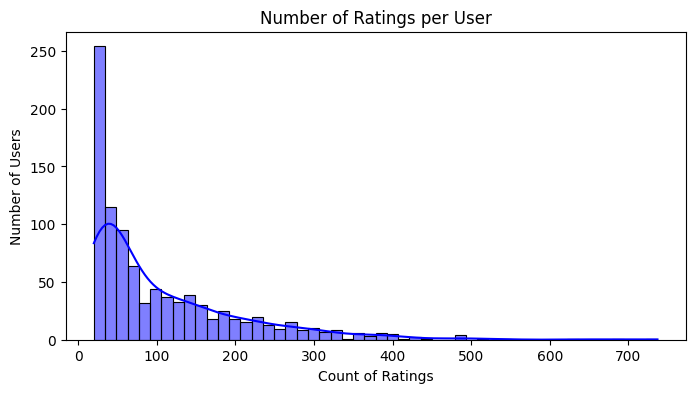

In [ ]:
#  User Activity 
user_counts = ratings.groupby('user_id').size()
plt.figure(figsize=(8, 4))
sns.histplot(user_counts, bins=50, kde=True, color='blue')
plt.title('Number of Ratings per User')
plt.xlabel('Count of Ratings')
plt.ylabel('Number of Users')
plt.show()


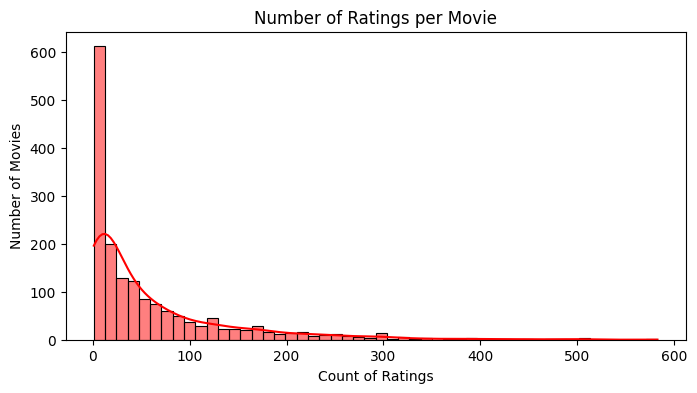

In [ ]:
# Movie Popularity 
movie_counts = ratings.groupby('movie_id').size()
plt.figure(figsize=(8, 4))
sns.histplot(movie_counts, bins=50, kde=True, color='red')
plt.title('Number of Ratings per Movie')
plt.xlabel('Count of Ratings')
plt.ylabel('Number of Movies')
plt.show()


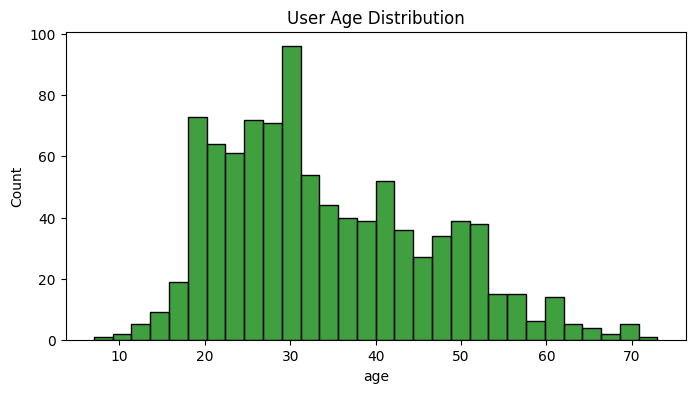

In [ ]:
# Demographics (Age) 
plt.figure(figsize=(8, 4))
sns.histplot(users['age'], bins=30, color='green')
plt.title('User Age Distribution')
plt.show()

In [11]:
print(ratings["rating"].mean())

3.52986


In [12]:
print(users['age'].mean())

34.05196182396607


In [ ]:
import numpy as np
from sklearn.metrics import r2_score

# Calculate the mean rating
mean_rating = ratings['rating'].mean() 

# True and predicted ratings
y_true = ratings['rating']
y_pred = np.full_like(y_true, mean_rating)

rmse_baseline = np.sqrt(np.mean((y_true - mean_rating)**2))

r2_baseline = r2_score(y_true, y_pred)

print(f"Mean rating: {mean_rating:.4f}")
print(f"RMSE if predicting mean rating ({mean_rating:.4f}) for all entries: {rmse_baseline:.4f}")
print(f"R² if predicting mean rating for all entries: {r2_baseline:.4f}")

Mean rating: 3.5299
RMSE if predicting mean rating (3.5299) for all entries: 1.1257
R² if predicting mean rating for all entries: -0.2216
